--- 0.28330326080322266 seconds ---
Circularities per label: {1: np.float64(3.8727287402382187), 2: np.float64(8.103698594166447), 3: np.float64(2.522707331431415), 4: np.float64(3.427088858287955), 5: np.float64(5.761818016461234), 6: np.float64(7.931078094857071), 7: np.float64(3.0666577140377367), 8: np.float64(8.267097289278098), 9: np.float64(6.987951023953255), 10: np.float64(2.9231141230669615), 11: np.float64(2.777307765687726), 12: np.float64(5.7219706941054715), 13: np.float64(3.149561005671122), 14: np.float64(2.2355276610647454)}


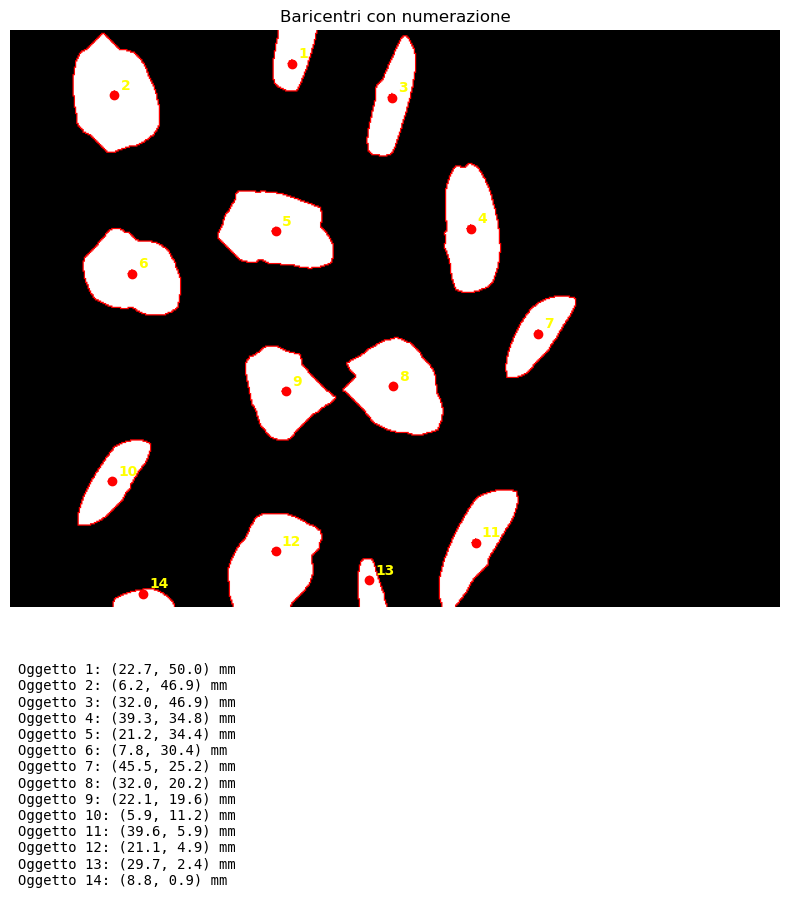

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time
from collections import deque
import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk

def trace_boundary(binary_image):
    start_time = time.time()
    
    h, w = binary_image.shape
    boundary_mask = np.zeros((h, w), dtype=np.uint8)
    visited = np.zeros((h, w), dtype=bool)
    labels = np.zeros((h, w), dtype=int)
    current_label = 1

    row_sums = np.sum(binary_image, axis=1)
    col_sums = np.sum(binary_image, axis=0)
    
    top = np.argmax(row_sums > 0)
    bottom = h - np.argmax(row_sums[::-1] > 0)
    left = np.argmax(col_sums > 0)
    right = w - np.argmax(col_sums[::-1] > 0)
    
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]

    def bfs(start_i, start_j):
        queue = deque([(start_i, start_j)])
        
        while queue:
            i, j = queue.popleft()
            
            if visited[i, j]:
                continue
            
            visited[i, j] = True
            boundary_mask[i, j] = 255
            labels[i, j] = current_label

            for dx, dy in directions:
                ni, nj = i + dx, j + dy
                if 0 <= ni < h and 0 <= nj < w and not visited[ni, nj]:
                    if binary_image[ni, nj] == 255:
                        boundary_found = any(
                            0 <= ni + dx2 < h and 0 <= nj + dy2 < w and binary_image[ni + dx2, nj + dy2] == 0
                            for dx2, dy2 in directions
                        )
                        if boundary_found:
                            queue.append((ni, nj))
    
    for i in range(top, bottom):
        for j in range(left, right):
            if binary_image[i, j] == 255 and not visited[i, j]:
                if any(
                    0 <= i + dx < h and 0 <= j + dy < w and binary_image[i + dx, j + dy] == 0
                    for dx, dy in directions
                ):
                    bfs(i, j)
                    current_label += 1

    print("--- %s seconds ---" % (time.time() - start_time))
    return boundary_mask, labels, current_label - 1

def compute_circularity(labels, num_labels):
    circularities = {}
    for label in range(1, num_labels + 1):
        coords = np.column_stack(np.where(labels == label))
        if coords.shape[0] < 2:
            continue
        centroid = np.mean(coords, axis=0)
        distances = np.linalg.norm(coords - centroid, axis=1)
        mean_dist = np.mean(distances)
        std_dist = np.std(distances)
        circularity = mean_dist / std_dist if std_dist != 0 else 0
        circularities[label] = circularity
    return circularities

def compute_homography(world_pts, image_pts):
    A = []
    for i in range(len(world_pts)):
        X, Y = world_pts[i]
        x, y = image_pts[i]
        A.append([-X, -Y, -1, 0, 0, 0, x*X, x*Y, x])
        A.append([0, 0, 0, -X, -Y, -1, y*X, y*Y, y])
    A = np.array(A)
    _, _, Vt = np.linalg.svd(A)
    H = Vt[-1].reshape(3, 3)
    return H / H[2, 2]

def image_to_world(H, img_pts):
    H_inv = np.linalg.inv(H)
    world_pts = []
    for pt in img_pts:
        img_coord = np.array([pt[0], pt[1], 1.0])
        world_coord = H_inv @ img_coord
        world_coord /= world_coord[2]
        world_pts.append(world_coord[:2])
    return np.array(world_pts)

def process_image():
    image_path = entry_path.get()
    erosion_iters = int(entry_iterations.get())
    border_thickness = int(entry_thickness.get())
    
    beans_img = cv2.imread(image_path)
    img_gray = cv2.cvtColor(beans_img, cv2.COLOR_BGR2GRAY)
    
    height, width = img_gray.shape
    border_x = int(height * 0.02)
    border_y = int(width * 0.02)
    img_cropped = img_gray[border_x:height-border_x, border_y:width-border_y]
    
    threshold = 75
    _, img_segmented = cv2.threshold(img_cropped, threshold, 255, cv2.THRESH_BINARY_INV)
    
    kernel_erode = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    img_eroded = cv2.erode(img_segmented, kernel_erode, iterations=erosion_iters)
    
    kernel_open = np.ones((3, 3), np.uint8)
    img_opened = cv2.morphologyEx(img_eroded, cv2.MORPH_OPEN, kernel_open)
    
    boundary_mask, labels, num_labels = trace_boundary(img_opened)
    colored_img = cv2.cvtColor(img_opened, cv2.COLOR_GRAY2BGR)
    
    circularities = compute_circularity(labels, num_labels)
    print("Circularities per label:", circularities)
    
    for i in range(border_thickness):
        dilated_mask = cv2.dilate(boundary_mask, np.ones((3, 3), np.uint8), iterations=i)
        colored_img[dilated_mask == 255] = [0, 0, 255]
    
    centroids = []
    for label in range(1, num_labels + 1):
        coords = np.column_stack(np.where(labels == label))
        if coords.size == 0:
            continue
        centroid = np.mean(coords, axis=0).astype(int)
        centroids.append((centroid[1], centroid[0]))  # x, y
        cv2.circle(colored_img, (centroid[1], centroid[0]), radius=3, color=(0, 0, 255), thickness=-1)

    centroids = np.array(centroids)
    
    img_original = Image.open(image_path)
    img_original.thumbnail((250, 250))
    img_tk = ImageTk.PhotoImage(img_original)
    label_original.config(image=img_tk)
    label_original.image = img_tk
    
    img_result = Image.fromarray(cv2.cvtColor(colored_img, cv2.COLOR_BGR2RGB))
    img_result.thumbnail((250, 250))
    img_result_tk = ImageTk.PhotoImage(img_result)
    label_result.config(image=img_result_tk)
    label_result.image = img_result_tk
    
    label_count.config(text=f"Boundaries found: {num_labels}")
    
    # === Trasformazione coordinate ===
    p_1_w = np.array([21, 14])
    p_2_w = np.array([56, 14])
    p_3_w = np.array([63, 35])
    p_4_w = np.array([28, 28])

    p_1_i = np.array([211, 338])
    p_2_i = np.array([514, 341])
    p_3_i = np.array([573, 159])
    p_4_i = np.array([271, 217])

    world_points = np.array([p_1_w, p_2_w, p_3_w, p_4_w], dtype=np.float64)
    image_points = np.array([p_1_i, p_2_i, p_3_i, p_4_i], dtype=np.float64)

    H = compute_homography(world_points, image_points)
    centroids_world = image_to_world(H, centroids)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [3, 1]})
    ax1.imshow(cv2.cvtColor(colored_img, cv2.COLOR_BGR2RGB))
    for i, (pt_img, pt_w) in enumerate(zip(centroids, centroids_world), start=1):
        x, y = pt_img
        ax1.plot(x, y, 'ro')
        ax1.text(x + 5, y - 5, str(i), color='yellow', fontsize=10, weight='bold')
    ax1.set_title("Baricentri con numerazione")
    ax1.axis('off')

    lines = [f"Oggetto {i}: ({Xw:.1f}, {Yw:.1f}) mm" for i, (Xw, Yw) in enumerate(centroids_world, start=1)]
    ax2.axis('off')
    ax2.text(0.01, 0.95, "\n".join(lines), fontsize=10, verticalalignment='top', family='monospace')

    plt.tight_layout()
    plt.show()

def select_file():
    filename = filedialog.askopenfilename()
    entry_path.delete(0, tk.END)
    entry_path.insert(0, filename)

# GUI
root = tk.Tk()
root.geometry("600x400")
root.title("Boundary Detection and Coordinate Transformation")

frame_controls = tk.Frame(root)
frame_controls.pack()

label_path = tk.Label(frame_controls, text="Image Path:")
label_path.grid(row=0, column=0)
entry_path = tk.Entry(frame_controls, width=50)
entry_path.grid(row=0, column=1)
btn_browse = tk.Button(frame_controls, text="Browse", command=select_file)
btn_browse.grid(row=0, column=2)

label_iterations = tk.Label(frame_controls, text="Erosion Iterations:")
label_iterations.grid(row=1, column=0)
entry_iterations = tk.Entry(frame_controls, width=10)
entry_iterations.grid(row=1, column=1)
entry_iterations.insert(0, "15")

label_thickness = tk.Label(frame_controls, text="Border Thickness:")
label_thickness.grid(row=2, column=0)
entry_thickness = tk.Entry(frame_controls, width=10)
entry_thickness.grid(row=2, column=1)
entry_thickness.insert(0, "1")

btn_process = tk.Button(root, text="Process Image", command=process_image)
btn_process.pack()

frame_images = tk.Frame(root)
frame_images.pack()

label_original = tk.Label(frame_images)
label_original.pack(side=tk.LEFT)

label_result = tk.Label(frame_images)
label_result.pack(side=tk.RIGHT)

label_count = tk.Label(root, text="")
label_count.pack()

root.mainloop()
